In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
df = pd.read_csv("Housing.csv")

Data Loading & Exploration

In [6]:
print("Shape:", df.shape)
df.head(10)

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [7]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [9]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [10]:
print("Target Column: price")
print(df['price'].describe())

Target Column: price
count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64


Data Cleaning

In [11]:
df.drop_duplicates(inplace=True)
print("Duplicates removed. New shape:", df.shape)

Duplicates removed. New shape: (545, 13)


In [12]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [13]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("After encoding, shape:", df.shape)
df.head()

After encoding, shape: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Model Building


In [14]:
X = df.drop('price', axis=1) #input
y = df['price'] #output or prediction

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_lr):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred_lr):.4f}")


Linear Regression
MAE  : 970,043
RMSE : 1,324,507
R²   : 0.6529


In [16]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_rf):,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f}")
print(f"R²   : {r2_score(y_test, y_pred_rf):.4f}")

Random Forest
MAE  : 1,021,546
RMSE : 1,400,566
R²   : 0.6119


In [17]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "R² Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


 Visualization

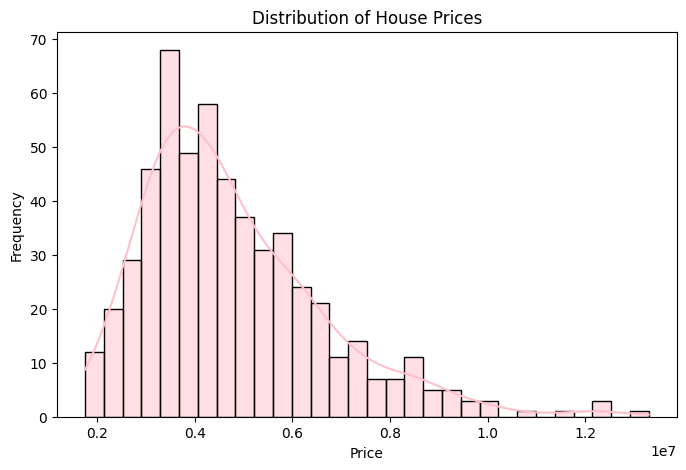

In [18]:
#Histogram of House Prices
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True, color="pink")

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("house_price_distribution.png", dpi=300)
plt.show()

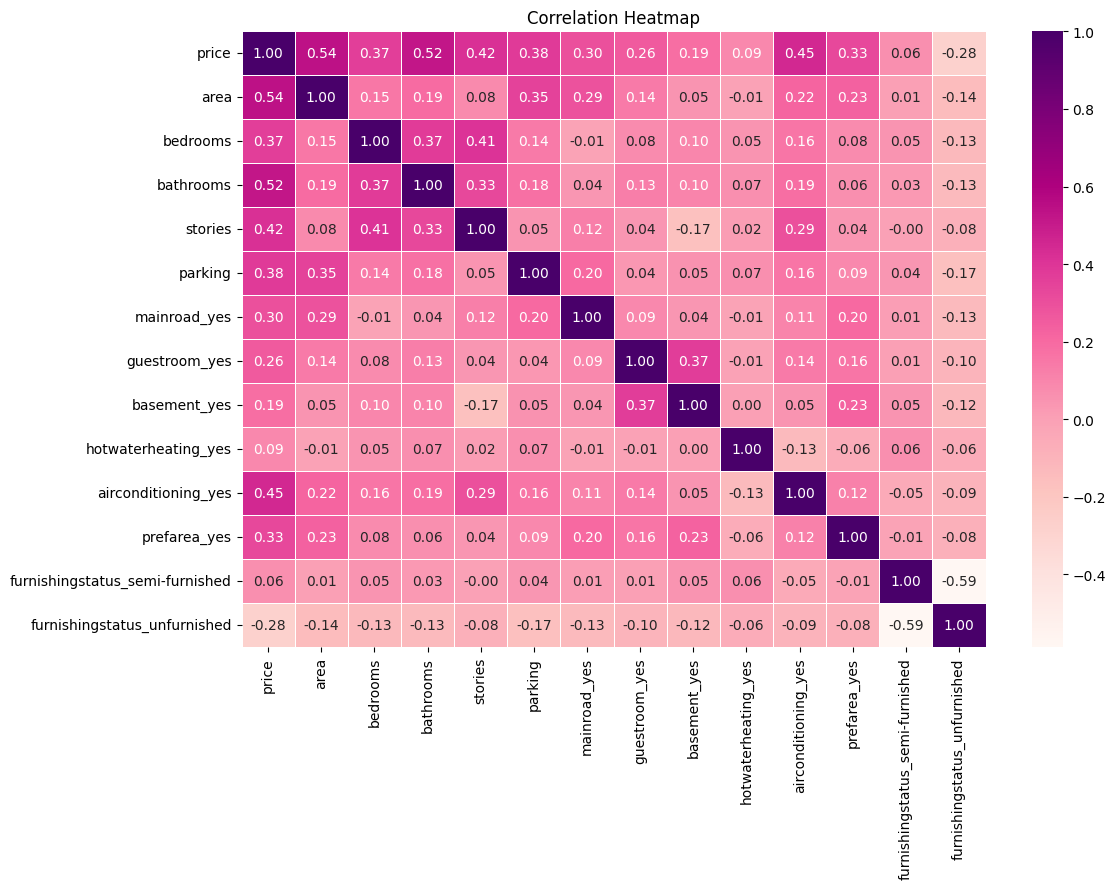

In [19]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="RdPu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

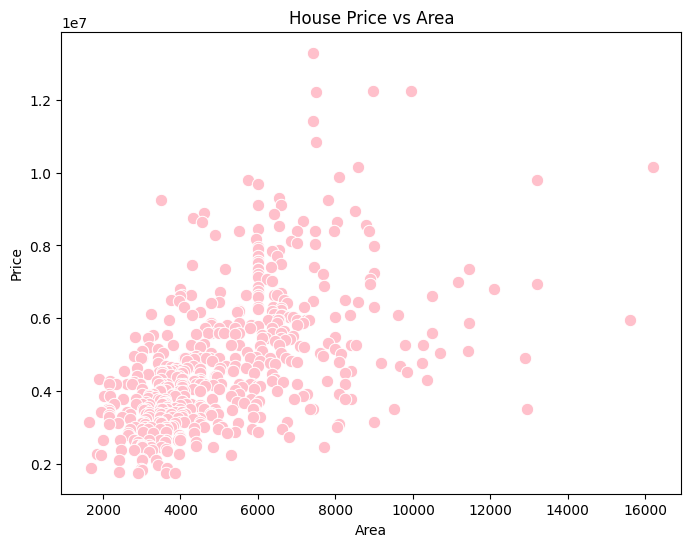

In [20]:
#Price vs Area
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="area",
    y="price",
    data=df,
    color="pink",
    s=80
)

plt.title("House Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price")

plt.savefig("price_vs_area.png", dpi=300)
plt.show()

/tmp/ipykernel_3514/2584586005.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


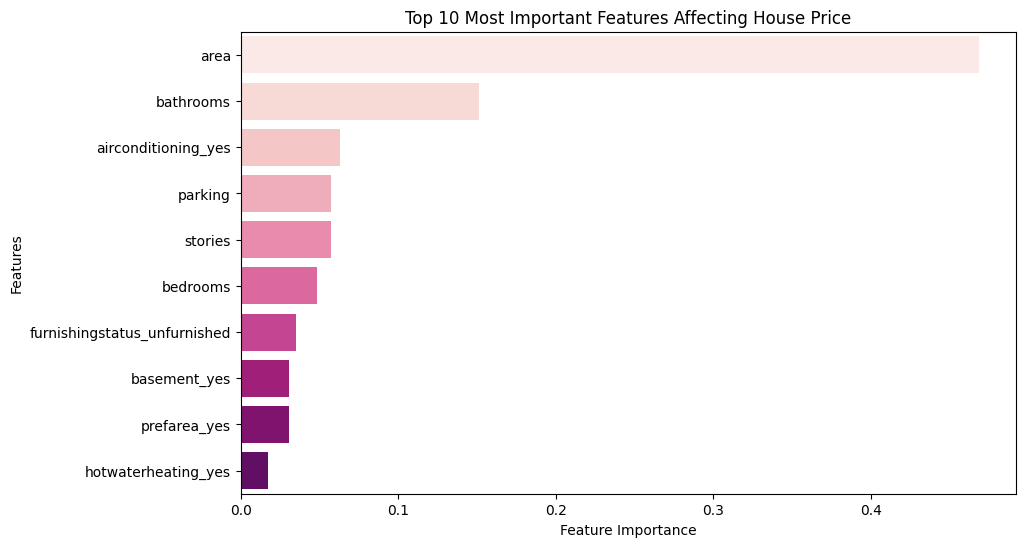

In [21]:
#Feature Importance
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    palette="RdPu"
)

plt.title("Top 10 Most Important Features Affecting House Price")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.savefig("feature_importance.png", dpi=300)
plt.show()

**Insights and summary**

It can be seen that area, bathrooms, AC, parking, stories, and bedrooms are some of the key variables that influence house prices.

It can be observed that the Linear Regression model outperformed the Random Forest model with an R² score of 0.653 which suggests that the Linear Regression model explains about 65% of the variation in house prices.

Furthermore, through the correlation heatmap, it can be seen that the larger the house size along with bathrooms, the higher is its price. Another notable observation is that furnished houses are priced higher compared to semi-furnished and unfurnished houses.

Based on the above observations, it can be said that the real estate business needs to focus on factors like area, bathrooms, and furnishing of houses while valuing houses.

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
from google.colab import files
import shutil, os


os.makedirs('HousePricePrediction/charts', exist_ok=True)


shutil.copy('Housing.csv', 'HousePricePrediction/')
shutil.copy('correlation_heatmap.png', 'HousePricePrediction/charts/')
shutil.copy('feature_importance.png', 'HousePricePrediction/charts/')
shutil.copy('house_price_distribution.png', 'HousePricePrediction/charts/')
shutil.copy('price_vs_area.png', 'HousePricePrediction/charts/')


shutil.make_archive('HousePricePrediction', 'zip', '.', 'HousePricePrediction')


files.download('HousePricePrediction.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>